# Tarea (Colab): Filtrado espacial y análisis en frecuencia (2D Fourier)

**Objetivo general:** demostrar, con evidencia visual y métricas básicas, que comprendes **qué hace** cada técnica, **por qué se usa**, **cómo afecta** el ruido/contraste/bordes y **cómo se interpreta** una imagen en el dominio de la frecuencia mediante **FFT 2D**.

**Entregables (en este mismo notebook):**
- Código ejecutable (sin errores).
- Figuras comparativas en cada sección.
- Respuestas breves (2–5 líneas) en las celdas de texto solicitadas.
- Conclusiones finales

**Integrantes:**
* Delgado Danny
* Simbaña Anthony
* Vásconez David

**Conclusiones:**
1. No existe una única técnica, el éxito depende del objetivo, los algoritmos y correcta selección de los parámetros (como el valor de sigma de Gauss).
2. Concluimos que un filtrado es adecuado cuando el residuo está compuesto únicamente por ruido blanco, es decir, puntos aleatorios sin estructura ni forma reconocible. Esto indica que el filtro eliminó el ruido sin afectar la información relevante de la imagen.
3. Determinamos que cuando en el residuo aparecen siluetas o formas reconocibles, como el contorno del barco, el filtrado ha sido excesivo. Esto evidencia que el filtro no solo está eliminando ruido, sino también detalles estructurales importantes de la imagen.
4. Conectividad (Canny), evidenciamos que la detección de bordes no es solo "restar píxeles". La promoción por asociación nos enseñó que el contexto importa: un punto débil solo es importante si tiene "amigos" fuertes cerca. Esto es lo que separa a un algoritmo común de uno profesional que entrega líneas continuas.
5. El análisis realizado en el dominio de la frecuencia mediante Fourier FFT 2D nos permitió observar que la forma de la función de transferencia es crítica para la calidad visual. Mientras que el filtro Ideal pasa bajo provocan el fenómeno de ringing (oscilaciones espaciales) debido a la discontinuidad en el dominio de la frecuencia, el filtro de Butterworth nos permitió observar que es la mejor forma por su transición suave y controlar la frecuencia de corte eliminando el ruido y ofreciendo un control más preciso que los kernels de convolución.
6. Finalmente, evidenciamos que el uso de funciones permite reducir el código, mantener una lógica más limpia y facilita la lectura del mismo.


## Sección 0 — Preparación del entorno

### Objetivo
Asegurar que el notebook sea reproducible (misma salida para cualquier persona).

### Qué debes hacer y por qué
- Importar librerías (NumPy, Matplotlib, scikit-image y/o OpenCV).
- Definir funciones auxiliares (mostrar imágenes, espectro FFT, etc.) para evitar repetición y mantener claridad.

In [80]:
# Importar las librerías principales para trabajar con filtros en las imágenes
import numpy as np                      # Para manejo de matrices y cálculos matemáticos
import matplotlib.pyplot as plt         # Para visualizar las imágenes y gráficas
import cv2                              # OpenCV para procesamiento de imagen avanzado
from skimage import io, filters, color, img_as_float  # Para utilidades específicas de imagen
from skimage.feature import canny
from scipy.fftpack import fft2,ifft2,fftshift,ifftshift # Para las transformadas de Fourier
from scipy.ndimage import convolve, gaussian_filter # Para aplicar filtro gausiano
from scipy.signal  import fftconvolve   # Para aplicar la convolución
from skimage.exposure import rescale_intensity  #Visualización corresta de residuales
from skimage.filters import gaussian

#Importar imagen de forma dinámica
!wget https://raw.githubusercontent.com/gitDavidVasconez/tareas/main/sailing_noise.png -O sailing_noise.png

# 1. Cargar la imagen
img = io.imread('sailing_noise.png', as_gray=True)

# Definir funciones auxiliares
# Función para visualizar las imagenes
def show_row(imgs, titles, comments=None, cmap="gray", figsize=(15, 4)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)

    if len(imgs) == 1:
        axes = [axes]

    for i, (ax, img, title) in enumerate(zip(axes, imgs, titles)):
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis('off')

    # Ajustar layout
    plt.tight_layout(rect=[0, 0.15, 1, 1])

    # Comentarios debajo de cada imagen
    if comments is not None:
        for i, ax in enumerate(axes):
            bbox = ax.get_position()
            x_center = (bbox.x0 + bbox.x1) / 2
            y_text = bbox.y0 - 0.08

            fig.text(
                x_center,
                y_text,
                comments[i],
                ha='center',
                va='top',
                fontsize=10
            )

    plt.show()



# Función para las Máscaras (Filtros Pasa-Bajo)
def create_masks(D0, n, order=2):
    # Crear malla de coordenadas
    x = np.linspace(-ccol, ccol, cols)
    y = np.linspace(-crow, crow, rows)
    X, Y = np.meshgrid(x, y)
    D = np.sqrt(X**2 + Y**2) # Distancia al centro

    # Filtro Ideal
    mask_ideal = np.zeros((rows, cols))
    mask_ideal[D <= D0] = 1

    # Filtro Butterworth
    mask_butter = 1 / (1 + (D / D0)**(n * order))

    # Filtro Gaussiano
    mask_gauss = np.exp(-(D**2) / (2 * (D0**2)))

    return mask_ideal, mask_butter, mask_gauss


--2026-02-10 00:43:33--  https://raw.githubusercontent.com/gitDavidVasconez/tareas/main/sailing_noise.png
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 124596 (122K) [image/png]
Saving to: ‘sailing_noise.png’

sailing_noise.png   100%[===================>] 121.68K  --.-KB/s    in 0.02s   

2026-02-10 00:43:33 (7.29 MB/s) - ‘sailing_noise.png’ saved [124596/124596]



## Sección 1 — Filtro pasa bajo: Gaussiano

### Objetivo
Entender el suavizado como atenuación de altas frecuencias y el trade-off: menos ruido vs pérdida de detalle.

### Qué debes hacer y por qué
- Aplicar Gaussiano variando σ (por ejemplo: 0.8, 1.5, 3.0) sobre la imagen proporcionada.
- Comparar resultados (¿cuándo reduce ruido? ¿cuándo borra bordes?).
- Mostrar el **residual**: `residual = imagen_ruidosa − imagen_filtrada`.

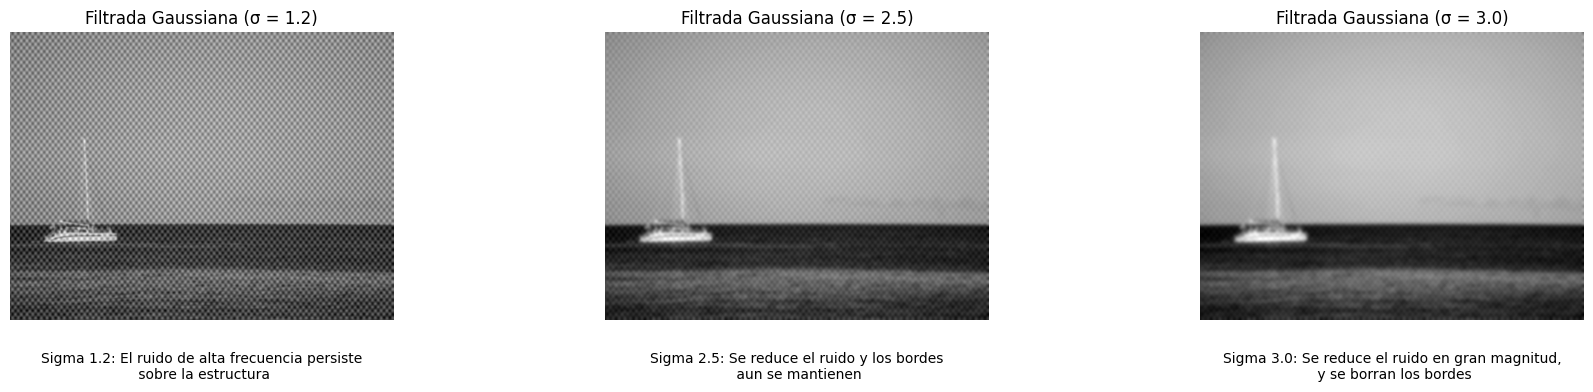

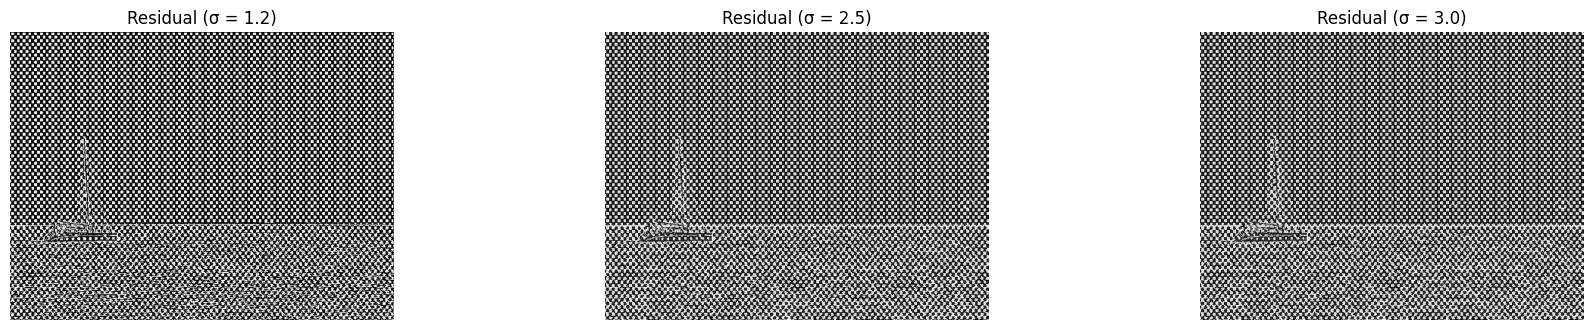

In [81]:
# Valores de sigma (desviación estándar) a probar
#sigmas = [0.8, 1.5, 3.0] para análisis inicial
sigmas = [1.2, 2.5, 3.0] # sigmas para la comparativa
comentarios = ['Sigma 1.2: El ruido de alta frecuencia persiste\n sobre la estructura',
               'Sigma 2.5: Se reduce el ruido y los bordes\n aun se mantienen',
               'Sigma 3.0: Se reduce el ruido en gran magnitud,\n y se borran los bordes']

imgs_filtradas = []
imgs_residual = []
titles_filtradas = []
titles_residual = []

# Visualización
for s in sigmas:
    # --- FILTRADO ---
    # Aplicamos el filtro gaussiano en el espacio
    img_filt = gaussian_filter(img, sigma=s)

    # --- CÁLCULO DEL RESIDUAL ---
    # Lo que el filtro "le quitó" a la imagen original
    residual = img - img_filt
    residual_vis = rescale_intensity(residual, in_range='image', out_range=(0,1))

    # Visualización de Imagen Filtrada
    imgs_filtradas.append(img_filt)
    #imgs_residual.append(np.abs(residual))  # mejor visualización
    imgs_residual.append(residual_vis)  # mejor visualización

    titles_filtradas.append(f"Filtrada Gaussiana (σ = {s})")
    titles_residual.append(f"Residual (σ = {s})")

  # Fila 1: Imágenes filtradas
show_row(
    imgs_filtradas,
    titles_filtradas,
    comments=comentarios,
    figsize=(18, 4)
)

  # Fila 2: Residuales
show_row(
    imgs_residual,
    titles_residual,
    figsize=(18, 4)
)


**Respuesta breve (2–5 líneas):**  
- ¿Qué σ te parece mejor para reducir ruido sin borrar demasiado borde?  
- Justifica con base en lo que viste (y el residual).

Basado en el análisis de los tres niveles (1.2, 2.5, 3.0), **el $\sigma = 2.5$ es el valor más optimo para este ejercicio**.

**Justificación visual**: Con σ = 2.5 el ruido se homogeniza y las superficies planas se limpian, permitiendo identificar los objetos sin distracciones, a diferencia de σ = 1.2.

**Justificación por residual**: El residual de σ = 2.5 es mayormente ruido blanco, mientras que en σ = 3.0 aparecen contornos del barco, indicando pérdida de información en la imagen.

**Resumen del trade-off**


*   $\sigma = 1.2$: El ruido sigue presente.
*   $\sigma = 2.5$: Punto de equilibrio. Máxima reducción de ruido sin comprometer visualmente los bordes principales.
*   $\sigma = 3.0$: Imágen con pérdida de detalles. Los bordes se difuminan en el fondo.

## Sección 2 — Filtro pasa alto: Laplaciano (realce de bordes)

### Objetivo
Entender la segunda derivada y por qué el Laplaciano realza cambios abruptos, pero también amplifica ruido.

### Qué debes hacer y por qué
- Implementar Laplaciano (por ejemplo con un kernel 3×3) y aplicarlo a:

  1) imagen proporcionada
  3) imagen suavizada (Gauss) → Laplaciano
- Comparar: Laplaciano directo vs Gauss→Laplaciano.

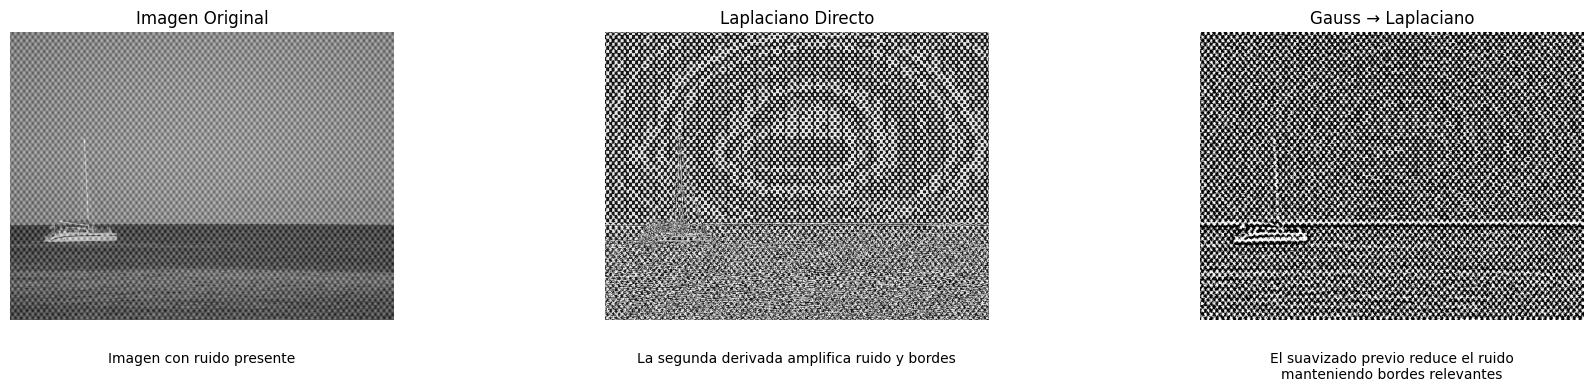

In [82]:
# Kernel Laplaciano 3×3
kernel_lap = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
])

# Laplaciano directo
lap_directo = convolve(img, kernel_lap)

# Gaussiano → Laplaciano
img_suave = gaussian_filter(img, sigma=2.5)
lap_gauss = convolve(img_suave, kernel_lap)

# Imágenes a mostrar
imgs = [
    img,
    np.abs(lap_directo),
    np.abs(lap_gauss)
]

titles = [
    "Imagen Original",
    "Laplaciano Directo",
    "Gauss → Laplaciano"
]

comments = [
    "Imagen con ruido presente",
    "La segunda derivada amplifica ruido y bordes",
    "El suavizado previo reduce el ruido\nmanteniendo bordes relevantes"
]

# Visualización
show_row(imgs,titles,comments=comments,figsize=(18, 4))


**Respuesta breve (2–5 líneas):**  
- ¿Por qué Gauss→Laplaciano suele verse “más estable” que Laplaciano directo sobre una imagen?

La combinación Gauss → Laplaciano es más estable porque el Laplaciano amplifica el ruido al tratarlo como bordes.
Aplicarlo directamente resalta cambios abruptos píxel a píxel, generando una imagen granular y caótica.

El suavizado Gaussiano previo promedia los píxeles y atenúa el ruido aleatorio.
Los bordes reales, al ser estructuras coherentes, se conservan aunque suavizados.
**En conjunto, el Gauss → Laplaciano actúa como un filtro que elimina ruido y realza bordes útiles**.


## Sección 3 — Operadores de borde: Sobel y Prewitt

### Objetivo
Diferenciar gradiente (1ª derivada) y cómo máscaras distintas estiman bordes en x/y.

### Qué debes hacer y por qué
- Calcular \(G_x\), \(G_y\) con Sobel y Prewitt.
- Calcular magnitud \(|G| = \sqrt{G_x^2 + G_y^2}\).
- Comparar grosor, sensibilidad al ruido y diferencias entre operadores.

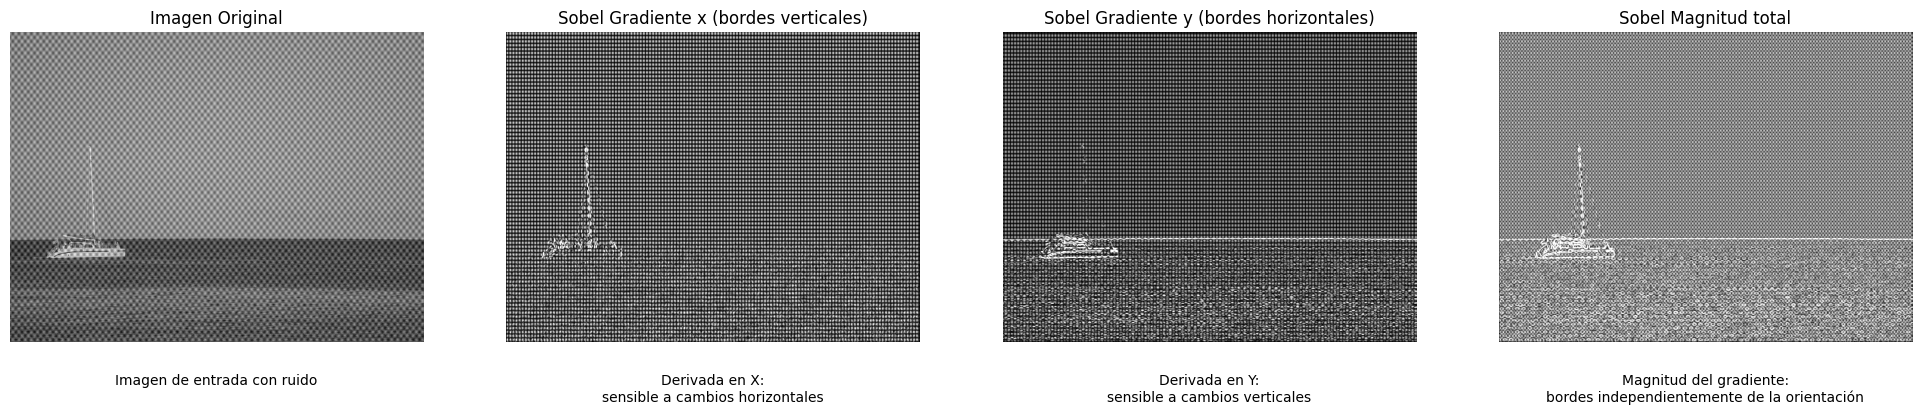

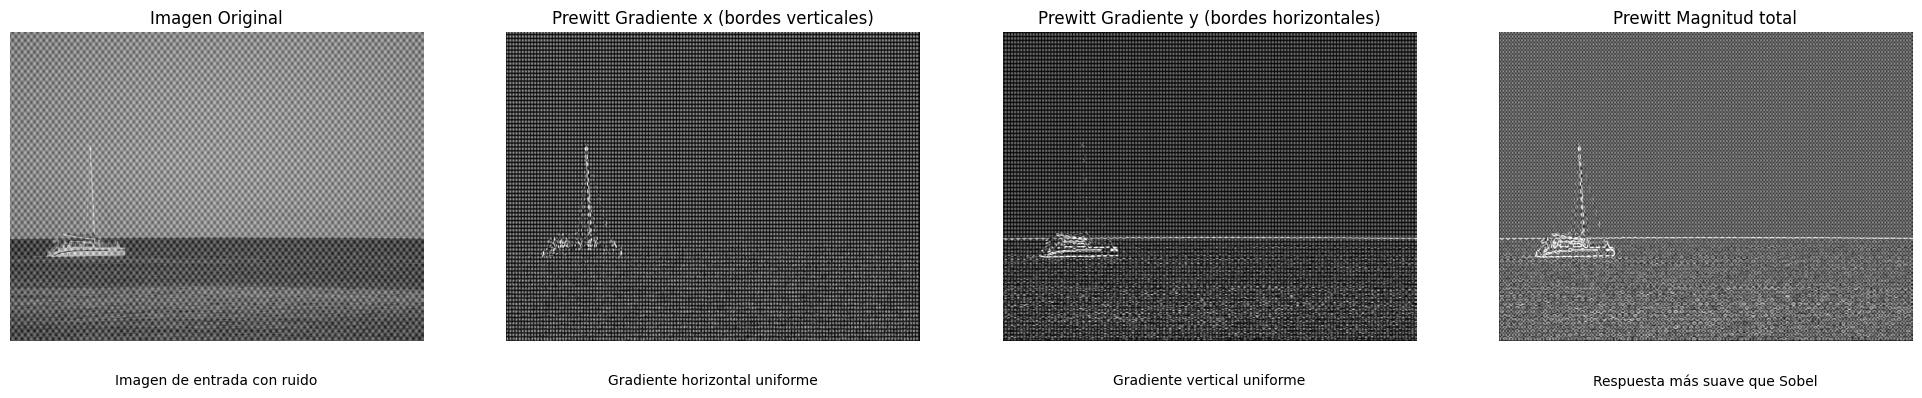

In [83]:
###########################################################################
#OPERADOR SOBEL
###########################################################################
# Definir los Kernels de Sobel (Matrices 3x3)
# Kernel para detectar cambios horizontales (bordes verticales)
sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]])

# Kernel para detectar cambios verticales (bordes horizontales)
sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

# Aplicar los filtros (convolución)
# cv2.filter2D aplica la matriz a la imagen
# Usamos cv2.CV_64F para evitar que los valores negativos se corten a 0
grad_x = cv2.filter2D(img, cv2.CV_64F, sobel_x)
grad_y = cv2.filter2D(img, cv2.CV_64F, sobel_y)

# Calcular la magnitud del gradiente (Combinar ambas direcciones)
# Es la raíz cuadrada de la suma de los cuadrados: sqrt(Gx^2 + Gy^2)
magnitud = np.sqrt(grad_x**2 + grad_y**2)

# Convertir a valores de 8 bits (0-255) para visualizar
grad_x_abs = cv2.convertScaleAbs(grad_x)
grad_y_abs = cv2.convertScaleAbs(grad_y)
magnitud_abs = cv2.convertScaleAbs(magnitud)

#Visualización

# Conversión para visualización
grad_x_abs = cv2.convertScaleAbs(grad_x)
grad_y_abs = cv2.convertScaleAbs(grad_y)
magnitud_abs = cv2.convertScaleAbs(magnitud)

# Visualización
imgs_sobel = [img,grad_x_abs,grad_y_abs,magnitud_abs]
titles_sobel = ["Imagen Original","Sobel Gradiente x (bordes verticales)", "Sobel Gradiente y (bordes horizontales)","Sobel Magnitud total"]
comments_sobel = ["Imagen de entrada con ruido","Derivada en X:\nsensible a cambios horizontales"
  ,"Derivada en Y:\nsensible a cambios verticales","Magnitud del gradiente:\nbordes independientemente de la orientación"]
show_row(imgs_sobel, titles_sobel,comments=comments_sobel,figsize=(20, 4))



###########################################################################
#OPERADOR PREWITT
###########################################################################
# 1. Definir los Kernels de Prewitt (Matrices 3x3)
# Diferencia: No hay peso extra en la fila/columna central
prewitt_x = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]])

prewitt_y = np.array([[-1, -1, -1],
                      [ 0,  0,  0],
                      [ 1,  1,  1]])

# 2. Aplicar los filtros (convolución)
# Usamos cv2.CV_64F para mantener la precisión de los gradientes negativos
grad_x_p = cv2.filter2D(img, cv2.CV_64F, prewitt_x)
grad_y_p = cv2.filter2D(img, cv2.CV_64F, prewitt_y)

# 3. Calcular la magnitud del gradiente
# sqrt(Gx^2 + Gy^2)
magnitud_p = np.sqrt(grad_x_p**2 + grad_y_p**2)

# 4. Convertir a valores de 8 bits para visualizar
grad_x_p_abs = cv2.convertScaleAbs(grad_x_p)
grad_y_p_abs = cv2.convertScaleAbs(grad_y_p)
magnitud_p_abs = cv2.convertScaleAbs(magnitud_p)

# Visualización
imgs_prewitt = [img,grad_x_p_abs,grad_y_p_abs,magnitud_p_abs]
titles_prewitt = ["Imagen Original","Prewitt Gradiente x (bordes verticales)", "Prewitt Gradiente y (bordes horizontales)","Prewitt Magnitud total"]
comments_prewitt = ["Imagen de entrada con ruido", "Gradiente horizontal uniforme","Gradiente vertical uniforme","Respuesta más suave que Sobel"]
show_row(imgs_prewitt,titles_prewitt, comments=comments_prewitt, figsize=(20, 4))


**Respuesta breve (2–5 líneas):**  
- Menciona una diferencia observable entre Sobel y Prewitt en tus resultados.

Prewitt: **Es más sensible al ruido**. Al tratar a todos los vecinos por igual, cualquier píxel "sucio" tiene el mismo peso que el central, lo que puede ensuciar un poco el borde.

Sobel: Es más robusto. El "2" en el centro actúa como un **pequeño suavizado** (filtro paso bajo). El resultado suele verse un poco más limpio porque ignora mejor las fluctuaciones pequeñas.

## Sección 4 — Detector Canny (bordes delgados + histéresis)

### Objetivo
Comprender por qué Canny es un pipeline (suavizado + gradiente + no-máximos + histéresis) y cómo los umbrales controlan conectividad.

### Qué debes hacer y por qué
- Ejecutar Canny con al menos 3 configuraciones de parámetros:
  - sensible (muchos bordes)
  - equilibrada
  - estricta (pocos bordes)
- Explicar el rol de umbrales e histéresis en 2–5 líneas.

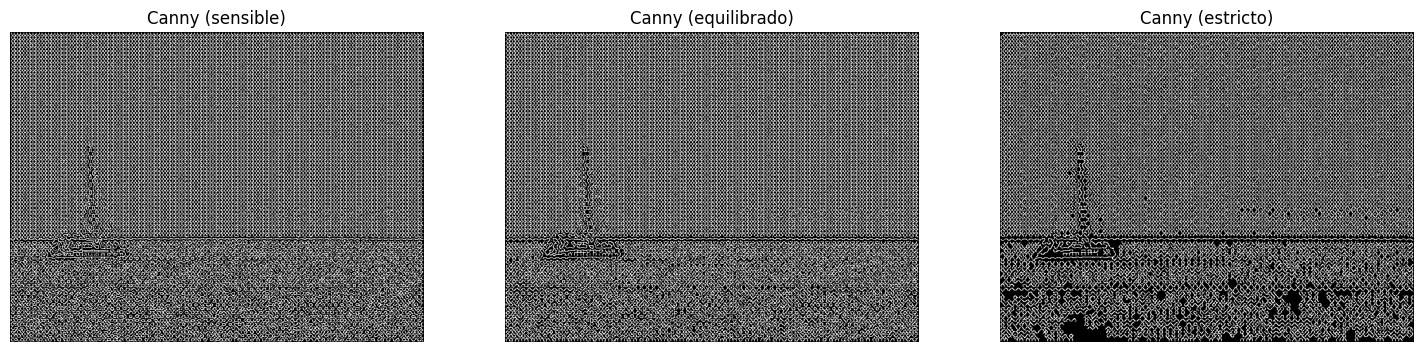

In [84]:
# Se usa img_as_float para que los thresholds (0.05, 0.08, 0.12) tengan sentido
img_gauss_noise = img_as_float(img)

# Canny en scikit-image: sigma y thresholds en [0,1]
c1 = canny(img_gauss_noise, sigma=1.0, low_threshold=0.05, high_threshold=0.15)
c2 = canny(img_gauss_noise, sigma=1.5, low_threshold=0.08, high_threshold=0.20)
c3 = canny(img_gauss_noise, sigma=2.0, low_threshold=0.12, high_threshold=0.30)

show_row([c1, c2, c3],
         ["Canny (sensible)", "Canny (equilibrado)", "Canny (estricto)"],
         cmap="gray", figsize=(15,4))



**Respuesta breve (2–5 líneas):**  
- ¿Qué cambia al subir los umbrales (low/high) en Canny? ¿Qué pasa con bordes débiles?

**¿Qué cambia al subir los umbrales (low/high) en Canny?**

Al subir los umbrales, el resultado pasa por un proceso de "purga":

Ganas claridad: Adiós al ruido y a las texturas irrelevantes.

Pierdes sutileza: Solo sobreviven los bordes con cambios de intensidades fuertes.

Arriesgas continuidad: Las líneas suaves se rompen y los contornos se vuelven "puntos y rayas".


**¿Qué pasa con bordes débiles?**

En el algoritmo de Canny los bordes débiles solo se conservan si están conectados a un borde fuerte. Si están aislados, se consideran ruido y se eliminan.

## Sección 6 — Transformada de Fourier 2D (FFT): espectro e interpretación

### Objetivo
Entender la relación de componentes en frecuencia.

### Qué debes hacer y por qué

- Calcular FFT2 y visualizar el espectro
- Aplicar filtro ideal, butterworth, y gausiano
- Comparar resultado e identificar con que filtro puedo eliminar mejor el ruido

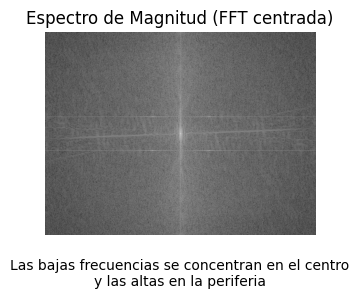

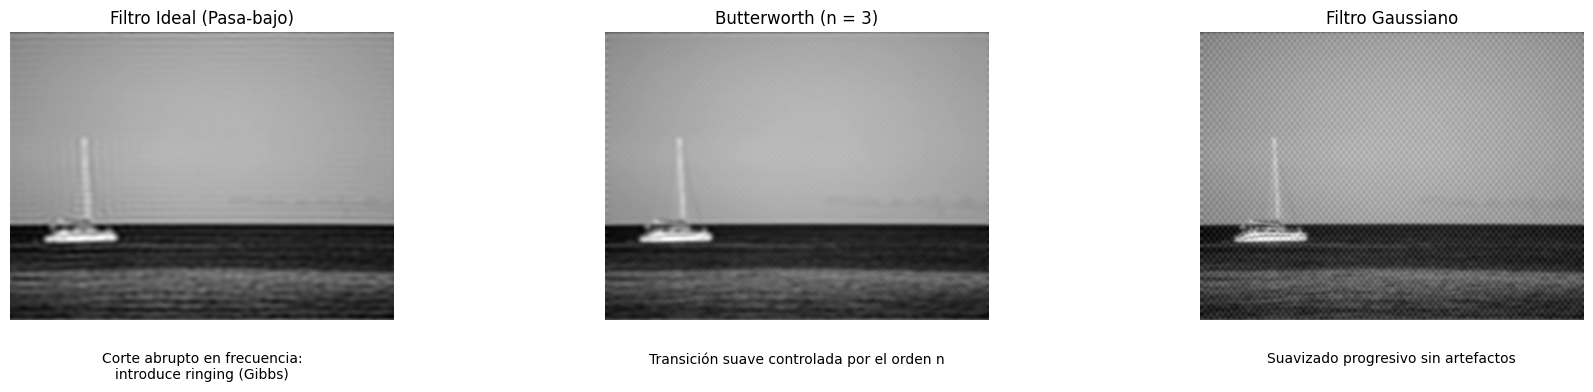

In [85]:
# Calcular la FFT y centrarla
f_transform = fft2(img)
f_shift = fftshift(f_transform) # Mueve las frecuencias bajas al centro

# Espectro de magnitud
magnitude_spectrum = 20 * np.log(np.abs(f_shift))

# 1. Preparar la imagen y su FFT
rows, cols = img.shape
crow, ccol = rows // 2 , cols // 2 # Centro de la imagen
#f_shift = fftshift(fft2(img))

# 3. Aplicar los filtros
D0 = 40   # Frecuencia de corte
n = 3     # orden Butterworth
m_ideal, m_butter, m_gauss = create_masks(D0, n)

results = []
masks = [m_ideal, m_butter, m_gauss]
titles = ["Filtro Ideal", "Butterworth (n="+str(n)+")", "Gaussiano"]

for m in masks:
    # Multiplicación en frecuencia
    f_filt = f_shift * m
    # Transformada Inversa para volver al espacio
    img_inversa = np.abs(ifft2(fftshift(f_filt)))
    results.append(img_inversa)


# Visualización
show_row(
    [magnitude_spectrum],
    ["Espectro de Magnitud (FFT centrada)"],
    comments=["Las bajas frecuencias se concentran en el centro\ny las altas en la periferia"],
    figsize=(6, 3)
)
titles_filtros = [    "Filtro Ideal (Pasa-bajo)",  f"Butterworth (n = {n})", "Filtro Gaussiano"]
comments_freq = ["Corte abrupto en frecuencia:\nintroduce ringing (Gibbs)", "Transición suave controlada por el orden n", "Suavizado progresivo sin artefactos"]

show_row(results, titles_filtros, comments=comments_freq, figsize=(18, 4))



**Respuesta breve (2–5 líneas):**  
- ¿Cual de los filtros (dominio de la frecuencia) elimina mejor el ruido?

El Filtro de Butterworth, es el mejor porque elimina mejor el ruido: Logra suprimir las altas frecuencias (ruido) de forma efectiva sin introducir el molesto efecto de **ringing** o ecos alrededor de los bordes del barco.